# Activation functions

The activation function (often refered as transfer function) of a node in an artificial neural network is a function that calculates the output of the node based on its individual inputs and their weights. The activation function segregates the incoming information into the "useful" and "not-so-useful" categories. The segregation plays a key role in helping a neural network properly function, ensuring that it learns from the useful information rather than get stuck analyzing the not-useful part (https://en.wikipedia.org/wiki/Activation_function, https://www.v7labs.com/blog/neural-networks-activation-functions).

The primary role of the Activation Function is to transform the summed weighted input from the node into an output value to be fed to the next hidden layer or as output. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1-Binary Step Activation Function

Binary step function depends on a threshold value that decides whether a neuron should be activated or not. 

The input fed to the activation function is compared to a certain threshold; if the input is greater than it, then the neuron is activated, else it is deactivated, meaning that its output is not passed on to the next hidden layer.

$$
  f(x)=\begin{cases}
    0, & \text{if $x<0$}.\\
    1, & \text{otherwise}.
  \end{cases}
$$

Here are some of the limitations of binary step function:
- It cannot provide multi-value outputs—for example, it cannot be used for multi-class classification problems. 
- The gradient of the step function is zero, which causes a hindrance in the backpropagation process.

## 2-Linear Activation Function

The linear activation function, also known as "no activation," or "identity function" (multiplied x1.0), is where the activation is proportional to the input.

The function doesn't do anything to the weighted sum of the input, it simply spits out the value it was given.

$$
f(x) = x
$$

However, a linear activation function has two major problems :
- It’s not possible to use backpropagation as the derivative of the function is a constant and has no relation to the input x. 
- All layers of the neural network will collapse into one if a linear activation function is used. No matter the number of layers in the neural network, the last layer will still be a linear function of the first layer. So, essentially, a linear activation function turns the neural network into just one layer.

## 3-Non-linear Activation functions

The linear activation function shown above is simply a linear regression model. 

Because of its limited power, this does not allow the model to create complex mappings between the network’s inputs and outputs. 

Non-linear activation functions solve the following limitations of linear activation functions:
- They allow backpropagation because now the derivative function would be related to the input, and it’s possible to go back and understand which weights in the input neurons can provide a better prediction.
- They allow the stacking of multiple layers of neurons as the output would now be a non-linear combination of input passed through multiple layers. Any output can be represented as a functional computation in a neural network.
Now, let’s have a look at ten different non-linear neural networks activation functions and their characteristics.

### 3.1-Sigmoid/Logistic Activation Function

This function takes any real value as input and outputs values in the range of 0 to 1. 

The larger the input (more positive), the closer the output value will be to 1.0, whereas the smaller the input (more negative), the closer the output will be to 0.0, as shown below.

$$
f(x) = \frac{1}{1+e^{-x}}
$$

To avoid overflow when x<0:

$$
f(x) = \frac{e^{x}}{1+e^{x}}
$$

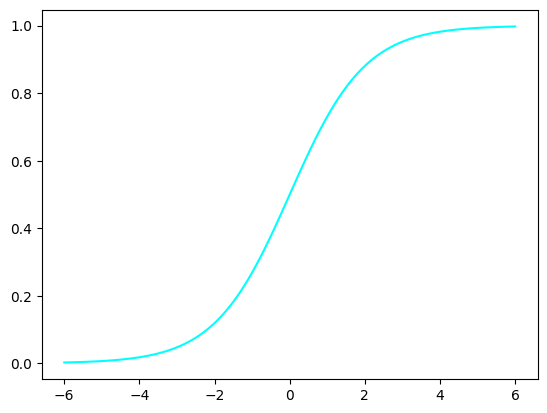

In [2]:
values = [np.exp(x)/(1+np.exp(x)) for x in np.arange(-6., 6.1, 0.1)]
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

Here’s why sigmoid/logistic activation function is one of the most widely used functions:

It is commonly used for models where we have to predict the probability as an output. Since probability of anything exists only between the range of 0 and 1, sigmoid is the right choice because of its range.
The function is differentiable and provides a smooth gradient, i.e., preventing jumps in output values. This is represented by an S-shape of the sigmoid activation function. 
The limitations of sigmoid function are discussed below:

The derivative of the function is 
$$
f'(x) = sigmoid(x)*(1-sigmoid(x)). 
$$

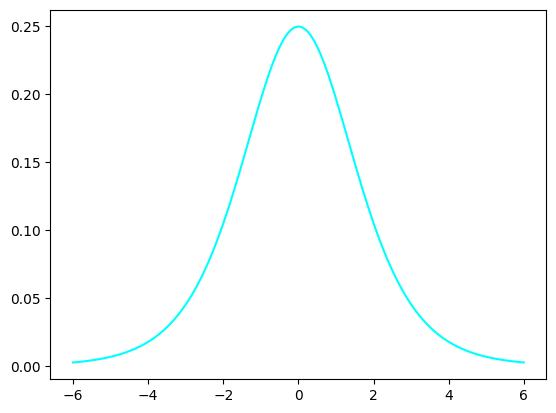

In [3]:
values = np.array([np.exp(x)/(1+np.exp(x)) for x in np.arange(-6., 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values*(1.-values), color="cyan")

As we can see from the above Figure, the gradient values are only significant for range -3 to 3, and the graph gets much flatter in other regions. 

It implies that for values greater than 3 or less than -3, the function will have very small gradients. As the gradient value approaches zero, the network ceases to learn and suffers from the Vanishing gradient problem.

The output of the logistic function is not symmetric around zero. So the output of all the neurons will be of the same sign. This makes the training of the neural network more difficult and unstable.

### 3.2-Hyperbolic Tangent Activation Function

Tanh function is very similar to the sigmoid/logistic activation function, and even has the same S-shape with the difference in output range of -1 to 1. In Tanh, the larger the input (more positive), the closer the output value will be to 1.0, whereas the smaller the input (more negative), the closer the output will be to -1.0.

$$
f(x)=\frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}
$$

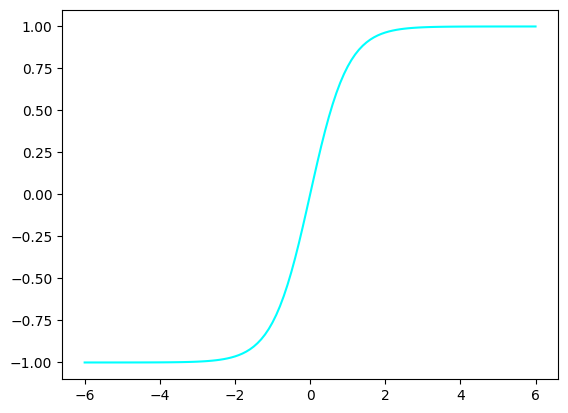

In [4]:
values = np.array([(np.exp(x)-np.exp(-x))/(np.exp(x)+np.exp(-x)) for x in np.arange(-6, 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

Advantages of using this activation function are:
- The output of the tanh activation function is Zero centered; hence we can easily map the output values as strongly negative, neutral, or strongly positive.
- Usually used in hidden layers of a neural network as its values lie between -1 to; therefore, the mean for the hidden layer comes out to be 0 or very close to it. It helps in centering the data and makes learning for the next layer much easier.

Have a look at the gradient of the tanh activation function to understand its limitations.

The derivative of the tanh function is:

$$
f'(x)=1-tanh^{2}(x)
$$

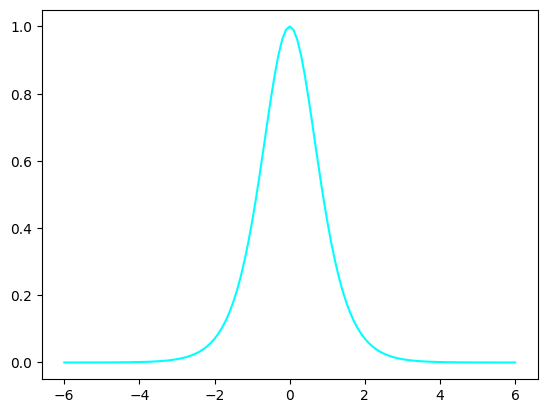

In [5]:
values = np.array([(np.exp(x)-np.exp(-x))/(np.exp(x)+np.exp(-x)) for x in np.arange(-6, 6.1, 0.1)])
derivatives = 1-values*values
plt.plot(np.arange(-6., 6.1, 0.1), derivatives, color="cyan")

As you can see— it also faces the problem of vanishing gradients similar to the sigmoid activation function. Plus the gradient of the tanh function is much steeper as compared to the sigmoid function.

Note:  Although both sigmoid and tanh face vanishing gradient issue, tanh is zero centered, and the gradients are not restricted to move in a certain direction. Therefore, in practice, tanh nonlinearity is always preferred to sigmoid nonlinearity.

### 3.3-ReLU Activation Function

ReLU stands for Rectified Linear Unit. 

Although it gives an impression of a linear function, ReLU has a derivative function and allows for backpropagation while simultaneously making it computationally efficient. 

The main catch here is that the ReLU function does not activate all the neurons at the same time. 

The neurons will only be deactivated if the output of the linear transformation is less than 0.

$$
f(x)=max(0,x)
$$

The advantages of using ReLU as an activation function are as follows:
- Since only a certain number of neurons are activated, the ReLU function is far more computationally efficient when compared to the sigmoid and tanh functions.
- ReLU accelerates the convergence of gradient descent towards the global minimum of the loss function due to its linear, non-saturating property.

The limitations faced by this function are:
- The Dying ReLU problem, which I explained below.

The derivative:
$$
  f'(x)=\begin{cases}
    0, & \text{if $x<0$}.\\
    1, & \text{otherwise}.
  \end{cases}
$$

The negative side of the graph makes the gradient value zero. Due to this reason, during the backpropagation process, the weights and biases for some neurons are not updated. This can create dead neurons which never get activated. 

All the negative input values become zero immediately, which decreases the model’s ability to fit or train from the data properly. 

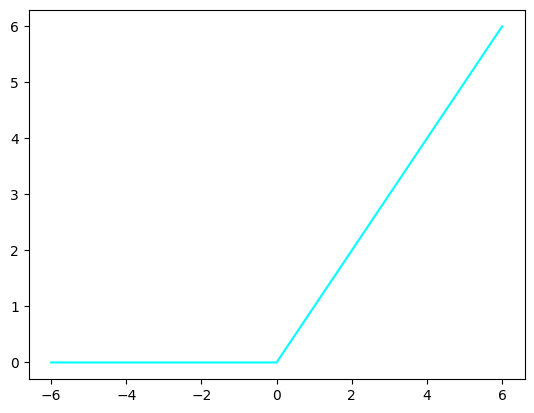

In [6]:
values = np.array([max(0, x) for x in np.arange(-6, 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

### 3.4-Leaky ReLU Activation Function

Leaky ReLU is an improved version of ReLU function to solve the Dying ReLU problem as it has a small positive slope in the negative area.

$$
f(x)=max(0.1x, x)
$$

The advantages of Leaky ReLU are same as that of ReLU, in addition to the fact that it does enable backpropagation, even for negative input values. 

By making this minor modification for negative input values, the gradient of the left side of the graph comes out to be a non-zero value. Therefore, we would no longer encounter dead neurons in that region. 

Here is the derivative of the Leaky ReLU function. 

The derivative:
$$
  f'(x)=\begin{cases}
    0.1, & \text{if $x=<0$}.\\
    1, & \text{otherwise}.
  \end{cases}
$$

The limitations that this function faces include:
- The predictions may not be consistent for negative input values. 
- The gradient for negative values is a small value that makes the learning of model parameters time-consuming.

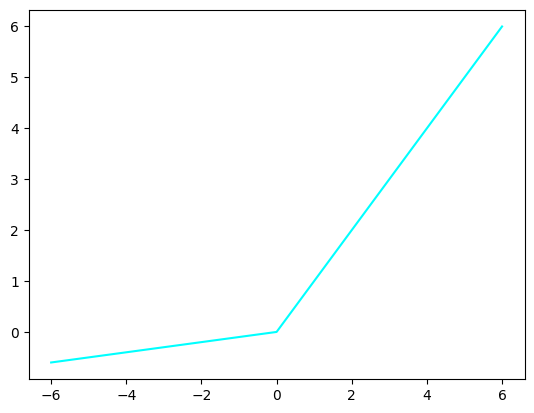

In [7]:
values = np.array([max(0.1*x, x) for x in np.arange(-6, 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

### 3.5-Parametric ReLU Activation Function

Parametric ReLU is another variant of ReLU that aims to solve the problem of gradient’s becoming zero for the left half of the axis. 

This function provides the slope of the negative part of the function as an argument a. By performing backpropagation, the most appropriate value of a is learnt.

$$
f(x)=max(ax, x)
$$

Where "a" is the slope parameter for negative values.

The parameterized ReLU function is used when the leaky ReLU function still fails at solving the problem of dead neurons, and the relevant information is not successfully passed to the next layer. 

This function’s limitation is that it may perform differently for different problems depending upon the value of slope parameter a.

The derivative:
$$
  f'(x)=\begin{cases}
    a, & \text{if $x=<0$}.\\
    1, & \text{otherwise}.
  \end{cases}
$$

### 3.6-Exponential Linear Units (ELU) Activation Function

Exponential Linear Unit, or ELU for short, is also a variant of ReLU that modifies the slope of the negative part of the function. 

ELU uses a log curve to define the negativ values unlike the leaky ReLU and Parametric ReLU functions with a straight line.

$$
  f(x)=\begin{cases}
    a(e^{x}-1), & \text{if $x<0$}.\\
    x, & \text{otherwise}.
  \end{cases}
$$

ELU is a strong alternative for f ReLU because of the following advantages:
- ELU becomes smooth slowly until its output equal to -α whereas RELU sharply smoothes.
- Avoids dead ReLU problem by introducing log curve for negative values of input. It helps the network nudge weights and biases in the right direction.

The limitations of the ELU function are as follow:
- It increases the computational time because of the exponential operation included
- No learning of the ‘a’ value takes place
- Exploding gradient problem

The derivative:
$$
  f'(x)=\begin{cases}
    a \times e^{x}, & \text{if $x<0$}.\\
    1, & \text{otherwise}.
  \end{cases}
$$

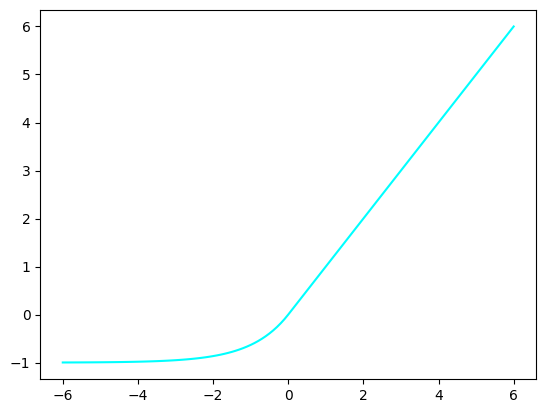

In [8]:
a = 1
values = np.array([a*(np.exp(x)-1) if x <=0 else x for x in np.arange(-6, 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

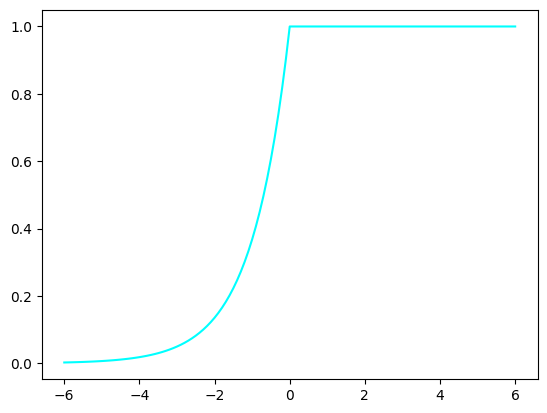

In [9]:
a = 1
values = np.array([a*np.exp(x) if x <=0 else 1 for x in np.arange(-6, 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

### 3.7-Softmax Activation Function

Assume that you have three classes, meaning that there would be three neurons in the output layer. Now, suppose that your output from the neurons is [1.8, 0.9, 0.68].

Applying the softmax function over these values to give a probabilistic view will result in the following outcome: [0.58, 0.23, 0.19]. 

The function returns 1 for the largest probability index while it returns 0 for the other two array indexes. Here, giving full weight to index 0 and no weight to index 1 and index 2. So the output would be the class corresponding to the 1st neuron(index 0) out of three.

You can see now how softmax activation function make things easy for multi-class classification problems.

$$
f(x_{i})=\frac{e^{x_{i}}}{\sum_{j} e^{x_{j}}}
$$

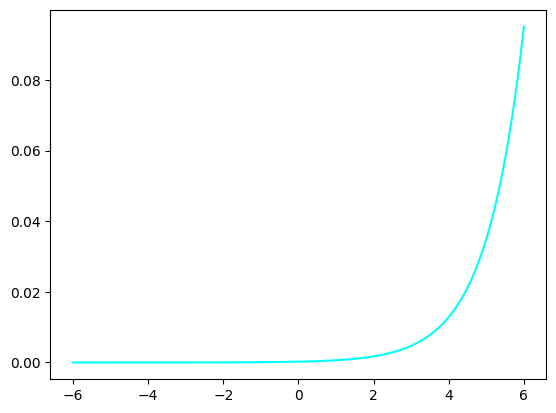

In [10]:
x = np.arange(-6.0, 6.1,0.1)
values = np.exp(x - np.max(x)) / np.exp(x - np.max(x)).sum()
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

### 3.8-Swish

It is a self-gated activation function developed by researchers at Google. 

Swish consistently matches or outperforms ReLU activation function on deep networks applied to various challenging domains such as image classification, machine translation etc. 

This function is bounded below but unbounded above i.e. Y approaches to a constant value as X approaches negative infinity but Y approaches to infinity as X approaches infinity.

$$
f(x) = \frac{x}{1+e^{-x}} = x \times sigmoid(x)
$$

Here are a few advantages of the Swish activation function over ReLU:
- Swish is a smooth function that means that it does not abruptly change direction like ReLU does near x = 0. Rather, it smoothly bends from 0 towards values < 0 and then upwards again.
- Small negative values were zeroed out in ReLU activation function. However, those negative values may still be relevant for capturing patterns underlying the data. Large negative values are zeroed out for reasons of sparsity making it a win-win situation.
- The swish function being non-monotonous enhances the expression of input data and weight to be learnt.

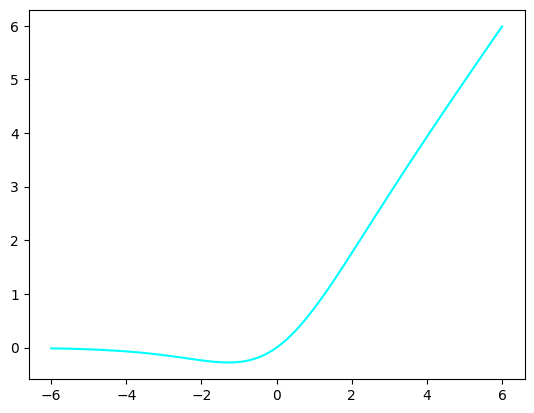

In [11]:
values = np.array([x/(1+np.exp(-x)) for x in np.arange(-6., 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")

### 3.9-Gaussian Error Linear Unit (GELU) Activation Function

The Gaussian Error Linear Unit (GELU) activation function is compatible with BERT, ROBERTa, ALBERT, and other top NLP models. This activation function is motivated by combining properties from dropout, zoneout, and ReLUs. 

ReLU and dropout together yield a neuron’s output. ReLU does it deterministically by multiplying the input by zero or one (depending upon the input value being positive or negative) and dropout stochastically multiplying by zero. 

RNN regularizer called zoneout stochastically multiplies inputs by one. 

We merge this functionality by multiplying the input by either zero or one which is stochastically determined and is dependent upon the input. We multiply the neuron input x by 

m ∼ Bernoulli(Φ(x)), where Φ(x) = P(X ≤x), X ∼ N (0, 1) is the cumulative distribution function of the standard normal distribution. 

This distribution is chosen since neuron inputs tend to follow a normal distribution, especially with Batch Normalization.

$$
f(x)=xP(X \le x) = x^{\phi(x)} = 0.5\left(1+tanh\left[\sqrt(2/\pi)(x+0.044715x^{3})\right]\right)
$$

GELU nonlinearity is better than ReLU and ELU activations and finds performance improvements across all tasks in domains of computer vision, natural language processing, and speech recognition.

### 3.10-Scaled Exponential Linear Unit (SELU)

SELU was defined in self-normalizing networks and takes care of internal normalization which means each layer preserves the mean and variance from the previous layers. SELU enables this normalization by adjusting the mean and variance. 

SELU has both positive and negative values to shift the mean, which was impossible for ReLU activation function as it cannot output negative values. 

Gradients can be used to adjust the variance. The activation function needs a region with a gradient larger than one to increase it.

$$
  f(\alpha,x)=\lambda\begin{cases}
    \alpha(e^{x}-1), & \text{if $x<0$}.\\
    x, & \text{otherwise}.
  \end{cases}
$$

SELU has values of alpha α and lambda λ predefined. 

Here’s the main advantage of SELU over ReLU:
- Internal normalization is faster than external normalization, which means the network converges faster.
- 
SELU is a relatively newer activation function and needs more papers on architectures such as CNNs and RNNs, where it is comparatively explored.

### 3.11-Softplus

$$
f(x) = log(1+e^{x})
$$

$$
f'(x) = sigmoid(x)
$$

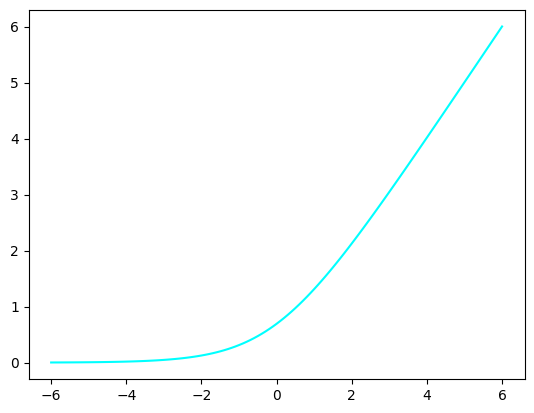

In [12]:
values = np.array([np.log(1. + np.exp(x)) for x in np.arange(-6., 6.1, 0.1)])
plt.plot(np.arange(-6., 6.1, 0.1), values, color="cyan")